In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/dataset-ventas-2025-2026-clean.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126827 entries, 0 to 126826
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   idtabla          126827 non-null  int64  
 1   fechaventa       126827 non-null  str    
 2   agente           126827 non-null  int64  
 3   supervisor       126827 non-null  int64  
 4   numSucursal      126827 non-null  int64  
 5   REGION           126827 non-null  str    
 6   paquete_vendido  126827 non-null  str    
 7   id_paquete       126827 non-null  int64  
 8   precio           126827 non-null  float64
 9   TipoServicio     126827 non-null  str    
dtypes: float64(1), int64(5), str(4)
memory usage: 9.7 MB


In [4]:
df["fechaventa"] = pd.to_datetime(df["fechaventa"])

In [5]:
# ventas_totales
ventas_totales = len(df)
print("Ventas totales: ", ventas_totales)
revenue_total = df["precio"].sum()
print("Total ingresos: $", f"{revenue_total:,.2f}")

Ventas totales:  126827
Total ingresos: $ 13,647,282.00


                      paquete_vendido     precio
0                   PLAN AT&T 100 100  3160349.0
1                  PLAN ALTAN 100 100  2984500.0
2            FOXSPORT PREMIUM 149 149  2803435.0
3              NETFLIX ANUNCIOS 80 80  1868789.0
4                  PLAN ALTAN 200 200   891600.0
5                   PLAN AT&T 200 200   698000.0
6                       MAX BASICO 80   424160.0
7  DISNEY STANDARD CON ANUNCIOS 60 60   216540.0
8                  PLAN ALTAN 300 300   165600.0
9                     HBO MAX 239 239   122129.0


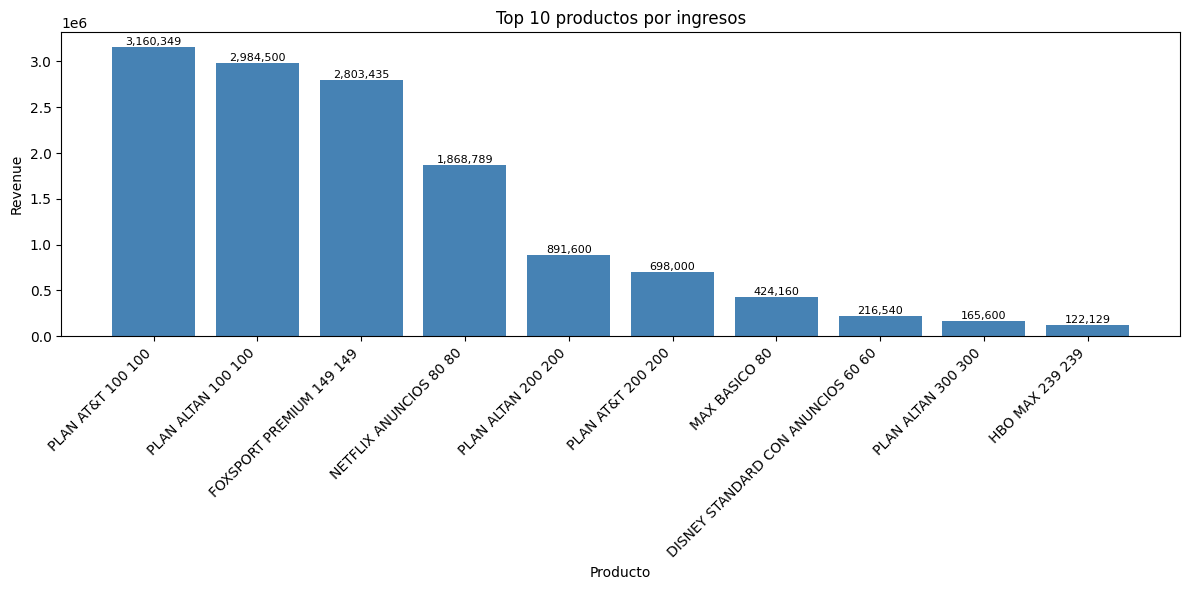

In [6]:
# Productos
# Analisis pareto
# Agrupar productos por ingreso
productos = (
    df.groupby("paquete_vendido")["precio"].sum().sort_values(ascending=False).reset_index()
)

top10_productos = productos.head(10)
print(top10_productos)
plt.figure(figsize=(12,6))

bars = plt.bar(top10_productos["paquete_vendido"], top10_productos["precio"], color="steelblue")

plt.title("Top 10 productos por ingresos")
plt.xlabel("Producto")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f'{y:,.0f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Calcular porcentaje de ingresos
productos["pct_ingresos"] = (
    productos["precio"] / revenue_total
)

# porcentaje de ingresos acumulado
productos["pct_acumulado"] = (
    productos["pct_ingresos"].cumsum()
)

In [8]:
# Dependendencia de productos top
print(productos.head(5))

            paquete_vendido     precio  pct_ingresos  pct_acumulado
0         PLAN AT&T 100 100  3160349.0      0.231574       0.231574
1        PLAN ALTAN 100 100  2984500.0      0.218688       0.450262
2  FOXSPORT PREMIUM 149 149  2803435.0      0.205421       0.655683
3    NETFLIX ANUNCIOS 80 80  1868789.0      0.136935       0.792617
4        PLAN ALTAN 200 200   891600.0      0.065332       0.857949


In [9]:
# Donde aparece el 80 de porcentaje
productos_80 = productos[productos["pct_acumulado"] <= 0.80]
print("El 80% de ventas estan en: \n ", productos_80)

El 80% de ventas estan en: 
              paquete_vendido     precio  pct_ingresos  pct_acumulado
0         PLAN AT&T 100 100  3160349.0      0.231574       0.231574
1        PLAN ALTAN 100 100  2984500.0      0.218688       0.450262
2  FOXSPORT PREMIUM 149 149  2803435.0      0.205421       0.655683
3    NETFLIX ANUNCIOS 80 80  1868789.0      0.136935       0.792617


In [10]:
# Productos con bajo desempeño
productos.tail(5)

,paquete_vendido,precio,pct_ingresos,pct_acumulado
40,PLAN ALTAN 150 150,50.0,0.000004,1.0
41,CAJA ADICIONAL DIGITAL 0,0.0,0.000000,1.0
42,CAJA ADICIONAL HD Y XVIEW 0,0.0,0.000000,1.0
43,MEGAS ASCENSO 0,0.0,0.000000,1.0
44,WIFI EXTENDER 0,0.0,0.000000,1.0


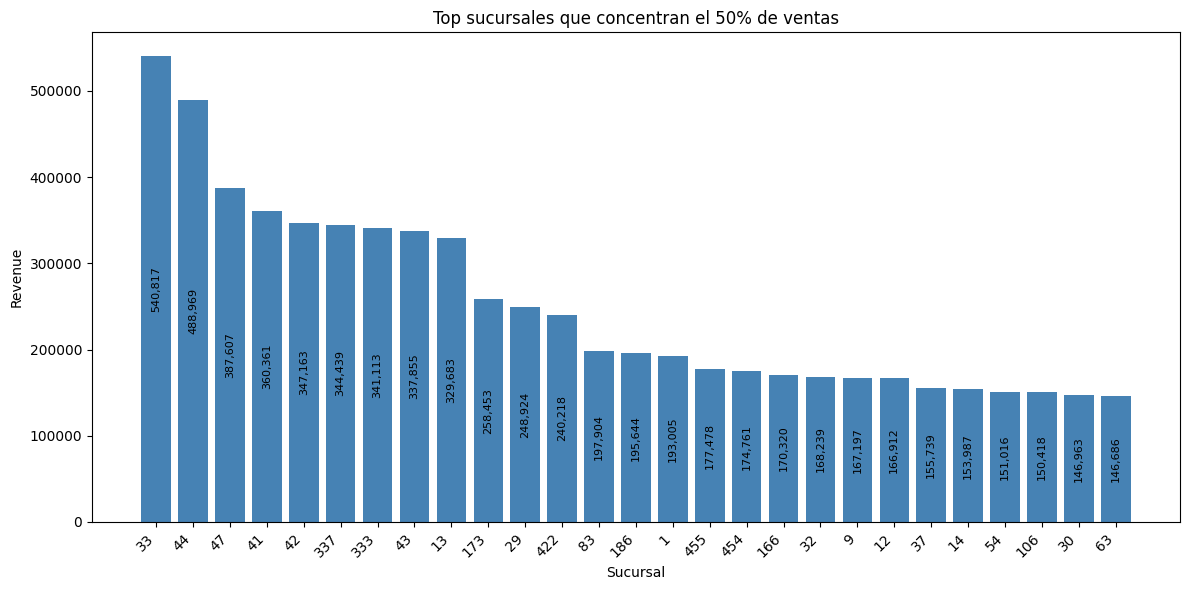

In [11]:
# Sucursales
sucursales = (
    df.groupby("numSucursal")["precio"].sum().sort_values(ascending=False).reset_index()
)

sucursales["pct_ingresos"] = (
    sucursales["precio"] / revenue_total
)

sucursales["pct_acumulado"] = (
    sucursales["pct_ingresos"].cumsum()
)

sucursales_50 = sucursales[
    sucursales["pct_acumulado"] <= 0.50
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    sucursales_50["numSucursal"].astype(str),
    sucursales_50["precio"],
    color="steelblue"
)

plt.title("Top sucursales que concentran el 50% de ventas")
plt.xlabel("Sucursal")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style='plain', axis='y')

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y * 0.5,  
        f'{y:,.0f}',
        ha='center',
        va='center',
        rotation=90,
        fontsize=8,
        color='black'  
    )

plt.tight_layout()
plt.show()

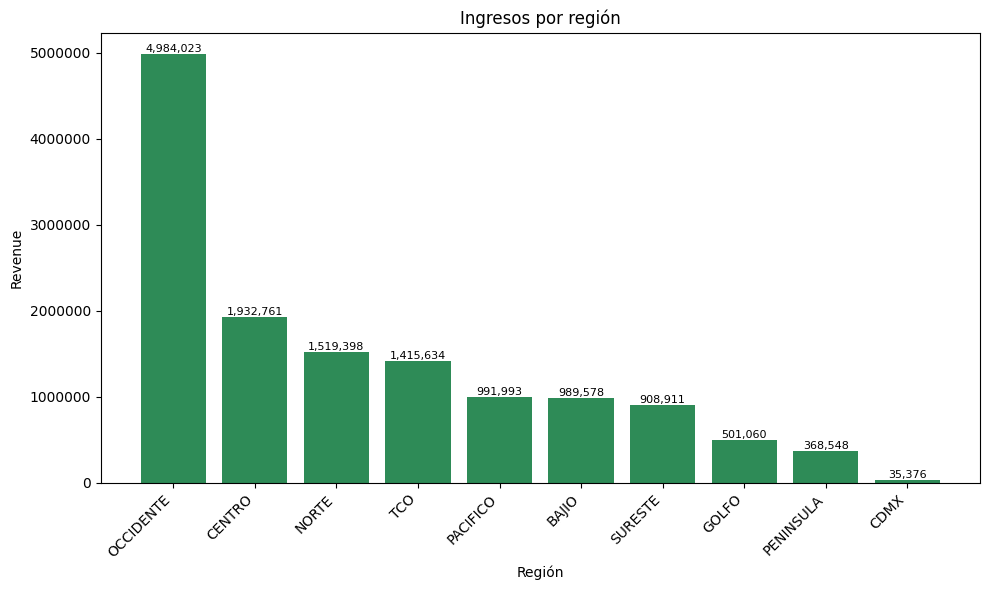

In [12]:
# Region
regiones = (
    df.groupby("REGION")["precio"].sum().sort_values(ascending=False).reset_index()
)

regiones["pct_ingresos"] = (
    regiones["precio"] / revenue_total
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    regiones["REGION"],
    regiones["precio"],
    color="seagreen"
)

plt.title("Ingresos por región")
plt.xlabel("Región")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")
plt.ticklabel_format(style='plain', axis='y')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f'{y:,.0f}',
             ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

In [13]:
promedio = regiones["precio"].mean()
print(promedio)

1364728.2


In [14]:
regiones_bajas = regiones[regiones["precio"] < promedio]
print("Regiones bajas \n", regiones_bajas)

Regiones bajas 
       REGION    precio  pct_ingresos
4   PACIFICO  991993.0      0.072688
5      BAJIO  989578.0      0.072511
6    SURESTE  908911.0      0.066600
7      GOLFO  501060.0      0.036715
8  PENINSULA  368548.0      0.027005
9       CDMX   35376.0      0.002592


In [15]:
# Vendedores
vendedores = (
    df.groupby("agente")["precio"].sum().sort_values(ascending=False).reset_index()
)
print(vendedores.head(10))

   agente    precio
0    5695  430426.0
1    5590  426759.0
2    5380  408797.0
3    5468  392755.0
4    5826  384521.0
5    5532  366159.0
6    4125  363665.0
7    3942  363148.0
8    5246  348704.0
9    5589  331811.0


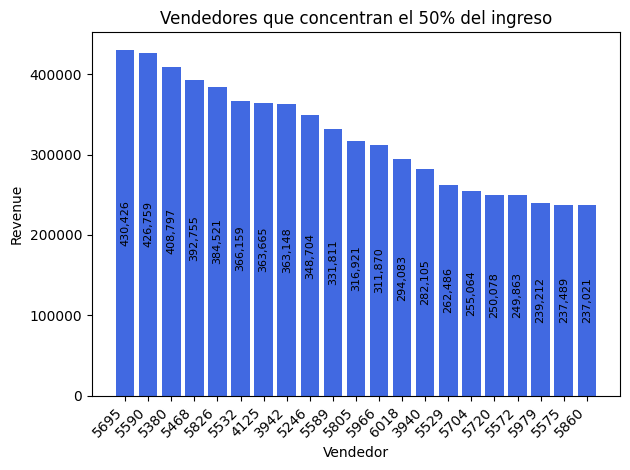

Total de vendedores:  483


In [16]:
vendedores["pct_ingresos"] = (
    vendedores["precio"] / revenue_total
)

vendedores["pct_acumulado"] = (
    vendedores["pct_ingresos"].cumsum()
)

top_50 = vendedores[
    vendedores["pct_acumulado"] <= 0.50
]

total_vendedores = df["agente"].nunique()
bars = plt.bar(
    top_50["agente"].astype(str),
    top_50["precio"],
    color="royalblue"
)

plt.title("Vendedores que concentran el 50% del ingreso")
plt.xlabel("Vendedor")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style='plain', axis='y')

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y * 0.5,  
        f'{y:,.0f}',
        ha='center',
        va='center',
        rotation=90,
        fontsize=8,
        color='black'  
    )

plt.tight_layout()
plt.show()
print("Total de vendedores: ", total_vendedores)